# BBC News Classification Kaggle Mini-Project

In this assignment, we will use matrix factorization to predict the category of a news article.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# For Nonnegative Matrix Factorization
import sklearn
from time import time
from sklearn.feature_extraction.text import TfidfVectorizer

# For supervised learning comparison
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
import statsmodels.formula.api as smf
import statsmodels.api as sm
from sklearn.model_selection import GridSearchCV, KFold

from scipy.sparse import coo_matrix, csr_matrix


## Importing Data and Initial EDA
1) Show a few visualizations like histograms. Describe any data cleaning procedures. Based on your EDA, what is your plan of analysis? 

In [2]:
bbc_test = pd.read_csv('bbcnewstest.csv')
bbc_train = pd.read_csv('bbcnewstrain.csv')

# Data set characteristics
bbc_train

,ArticleId,Text,Category
0,1833,worldcom ex-boss launches defence lawyers defe...,business
1,154,german business confidence slides german busin...,business
2,1101,bbc poll indicates economic gloom citizens in ...,business
3,1976,lifestyle governs mobile choice faster bett...,tech
4,917,enron bosses in $168m payout eighteen former e...,business
...,...,...,...
1485,857,double eviction from big brother model caprice...,entertainment
1486,325,dj double act revamp chart show dj duo jk and ...,entertainment
1487,1590,weak dollar hits reuters revenues at media gro...,business
1488,1587,apple ipod family expands market apple has exp...,tech


We see that this data consists of a unique identifier, ArticleId, the text, and a category label.  The data has 1490 rows and 3 columns.  Let's look at a histogram to see how categories are distributed across the articles.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1490 entries, 0 to 1489
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   ArticleId  1490 non-null   int64 
 1   Text       1490 non-null   object
 2   Category   1490 non-null   object
dtypes: int64(1), object(2)
memory usage: 35.1+ KB
None


<Axes: xlabel='Category'>

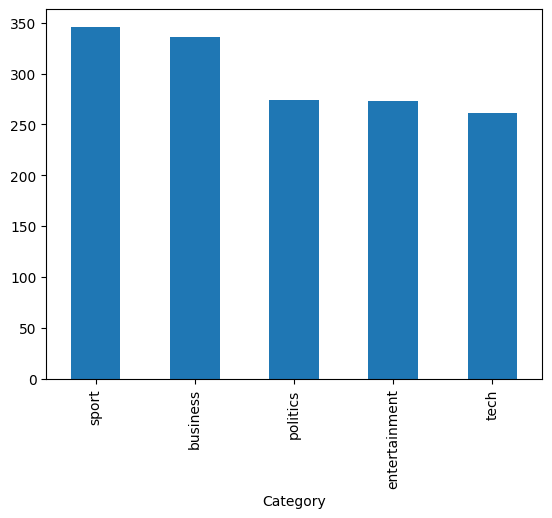

In [3]:
# 
print(bbc_train.info())
bbc_train['Category'].value_counts().plot(kind = "bar")

These category sizes are similar enough that we can work with the data as is.  I will not be cleaning the data further.  My plan is to encode the data in a matrix using TF-IDF and find latent factors to build a model to classify the text.

## Preprocessing and Word Statistics
2) Pick a method and process the raw texts to word embedding.  You can refer to any resource as needed, but make sure you “demonstrate” your understanding- please include explaining in your own words, discussions, and your interpretation. Also importantly, please have a reference list at the end of the report.

3) Briefly explain the method(s) and how they work in your own words. Also, do exploratory data analysis such as word statistics and/or visualization.

In [8]:
# Separating text data from category labels
X_train = bbc_train['Text']
y_train = bbc_train['Category']

Now we need to do some data preprocessing to turn the text into numerical data.

Below, I am using the TF-IDF method to turn the text data into a matrix which can be analyzed.  In TF-IDF, for each document/text/article (document), each word earns two scores: a term frequency score (TF) and an inverse document frequency score (IDF).  These scores are multiplied together to get the numeric value for the term and document pair in the TF-IDF matrix.  TF is obtained by a count of times the term occurs in the document, divided by the total number of terms in the document. In most explanations, the IDF is the *log* of the quantity obtained by dividing the total number of documents in the dataset by the number of documents in the dataset containing the word.  

However, in the default scikit-learn implementation, one is added to both the numerator and denominator before taking the log when calculating IDF, and one is added after taking the logarithm.  In addition, TFIDF scores are normalized by default.  

Using "stop_words = 'english'" tells the vectorizer to ignore words like "in", "the", "a", etc.

https://scikit-learn.org/stable/modules/generated/sklearn.feature_extraction.text.TfidfTransformer.html#sklearn.feature_extraction.text.TfidfTransformer
https://stackoverflow.com/questions/55292533/interpret-tf-idf-scores-from-sklearn-tfidfvectorizer


In [9]:

vectorizer_initial = TfidfVectorizer(stop_words='english')
M_initial = vectorizer_initial.fit_transform(X_train)
print(M_initial)
vectorizer_initial.get_feature_names_out()

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 213866 stored elements and shape (1490, 24456)>
  Coords	Values
  (0, 24187)	0.49389312320548195
  (0, 8401)	0.08289314080278484
  (0, 3616)	0.03638612576344087
  (0, 12970)	0.05416878571127764
  (0, 6543)	0.04042165657730414
  (0, 12999)	0.14705326655985523
  (0, 6551)	0.04901775551995174
  (0, 4738)	0.08225808074242229
  (0, 3191)	0.05839125068723239
  (0, 7743)	0.34430610834747316
  (0, 2965)	0.054877013689497996
  (0, 9445)	0.17204131369534081
  (0, 4639)	0.12126496973191242
  (0, 4165)	0.028519043809447787
  (0, 5298)	0.0529416199197389
  (0, 23948)	0.07276527365464272
  (0, 24095)	0.11294700036681521
  (0, 6250)	0.06889036350113473
  (0, 5771)	0.22256783272138428
  (0, 10656)	0.03455565170481055
  (0, 11909)	0.052892665673459745
  (0, 1336)	0.348945082661093
  (0, 1750)	0.06400855405163985
  (0, 7039)	0.047544583050883306
  (0, 12077)	0.0661410709942484
  :	:
  (1489, 13757)	0.15597873460683187
  (1489, 17618)	0.130000

array(['00', '000', '0001', ..., 'zurich', 'zutons', 'zvonareva'],
      dtype=object)

We see that in the resulting vectorization, there is a row for each article and a column for each term kept by the vectorizer after stop words were removed.  From the list of terms, we see that the default setting in the scikit-learn implementation of the TF-IDF algorithm includes numerical values as 'feature terms'.  

The vectorizer can be tuned, but first lets look at what we have in this implementation.

<function matplotlib.pyplot.show(close=None, block=None)>

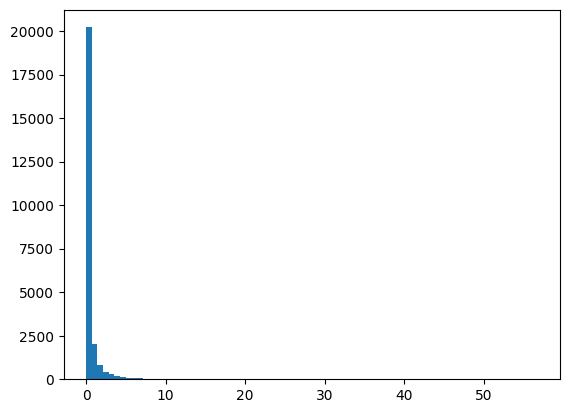

In [10]:
# plotting a histogram of column sums
plt.hist(M_initial.toarray().sum(axis = 0), bins = 80, label = 'Histogram of TFIDF score totals')
plt.xlabel = "TFIDF Totals for each term"
plt.ylabel = "Count"
plt.show

We see that a bulk of the terms in the vectorization have a near 0 total TF-IDF score.  We need to decrease the number of terms used in some meaningful way.  

I found an article on tuning TF-IDF using the ngram_range and max_features parameters.  Right now, the vectorizer is using a "bag of words" approach.  Each word is considered separately and out of context.  Using n-grams allows the vectorizer to use phrases of length n as terms in the analysis.  However, even just allowing all 2-grams would roughly square the number of terms used by the vectorizer, so it quickly becomes unmanageable to allow all n-grams for a data set in general.  Limiting the maximum number of terms used by the vectorizer allows us to keep a meaningful set of data.

I am completely new to NLP and I'm wanting to get on to the focus of the assignment, so I'm going to allow up to 3-grams and I'm also going to keep 2000 features.  A look at the feature names below shows that concepts like "world cup" and "young people" are showing up in the feature set, which seems to justify our choice of keeping 2-grams, at least.

https://codesignal.com/learn/courses/introduction-to-tf-idf-vectorization-in-python/lessons/customizing-tf-idf-vectorization-parameters-in-nlp

In [21]:
vectorizer = TfidfVectorizer(stop_words='english', ngram_range= (1,3), max_features= 2000)
M_train = vectorizer.fit_transform(X_train)
print(M_train)
feature_names = vectorizer.get_feature_names_out()
print(feature_names[1900:])

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 133865 stored elements and shape (1490, 2000)>
  Coords	Values
  (0, 1976)	0.5541409034962578
  (0, 647)	0.09300489879262175
  (0, 250)	0.0408247040866225
  (0, 507)	0.04535251098696437
  (0, 346)	0.0922923706380694
  (0, 601)	0.38630644767971434
  (0, 755)	0.1930278526476983
  (0, 339)	0.13605753296089312
  (0, 284)	0.03199795251419557
  (0, 400)	0.05939972782871493
  (0, 844)	0.038770938806206044
  (0, 76)	0.3915113094132836
  (0, 548)	0.053344330929685865
  (0, 1784)	0.05225296768864568
  (0, 788)	0.04024496920890468
  (0, 28)	0.07938995543178308
  (0, 1038)	0.03896950898681734
  (0, 728)	0.05999902737313552
  (0, 736)	0.035205363138423915
  (0, 1201)	0.15240843181668595
  (0, 828)	0.04951988979601491
  (0, 148)	0.04535251098696437
  (0, 1603)	0.037302324711070235
  (0, 622)	0.05455949586649568
  (0, 1516)	0.05260455601662078
  :	:
  (1489, 867)	0.0658586404963968
  (1489, 913)	0.06405573496445391
  (1489, 887)	0.05968455

## Model Building and Training (Unsupervised)

In the Kaggle competition, the training data has labels (category). Thus, it can be solved using supervised learning. In general, the more labeled data we have, the more accurate the supervised learning model will be. But unsupervised learning can be powerful even when there is a small number of labels or no labels. This assignment will apply an unsupervised approach, especially the matrix factorization method, to discover topics in the news articles and use the labels to check the accuracy.

Here are some steps to guide this section: 
1) Think about this and answer: when you train the unsupervised model for matrix factorization, should you include texts (word features) from the test dataset or not as the input matrix? Why or why not?
2) Build a model using the matrix factorization method(s) and predict the train and test data labels. Choose any hyperparameter (e.g., number of word features) to begin with.
3) Measure the performances on predictions from both train and test datasets. You can use accuracy, confusion matrix, etc., to inspect the performance. You can get accuracy for the test data by submitting the result to Kaggle. 
4) Change hyperparameter(s) and record the results. We recommend including a summary table and/or graphs.
5) Improve the model performance if you can- some ideas may include but are not limited to; using different feature extraction methods, fit models in different subsets of data, ensemble the model prediction results, etc. 

In [1]:
# Use sklearn matric factorization

## Supervised methods for comparison

Use the following steps to guide your work:

1) Pick and train a supervised learning method(s) and compare the results (train and test performance)
2) Discuss comparison with the unsupervised approach. You may try changing the train data size (e.g., Include only 10%, 20%, 50% of labels, and observe train/test performance changes). Which methods are data-efficient (require a smaller amount of data to achieve similar results)? What about overfitting?

## Results and comparisons

Go onto k- means clustering and 

class sklearn.decomposition.NMF(n_components='auto', *, init=None, solver='cd', beta_loss='frobenius', tol=0.0001, max_iter=200, random_state=None, alpha_W=0.0, alpha_H='same', l1_ratio=0.0, verbose=0, shuffle=False)

In [9]:
from sklearn.decomposition import NMF

In [ ]:
MF = NMF(n_components=5, init=None, solver='cd', beta_loss='frobenius', 
                                tol=0.0001, max_iter=200, random_state=None, alpha_W=0.0, alpha_H='same', 
                                l1_ratio=0.0, verbose=0, shuffle=False)
matrix_factorization = MF.fit_transform(X_vector)
MF.components_.shape

In [28]:
X_vector.shape

(1490, 24456)

In [30]:
matrix_factorization.shape

(1490, 5)

In [ ]:
def label_permute_compare(ytdf,yp,n=5):
    """
    ytdf: labels dataframe object
    yp: clustering label prediction output
    Returns permuted label order and accuracy. 
    Example output: (3, 4, 1, 2, 0), 0.74 
    """
    Y = ytdf
    Y['Predicted'] = yp
    list_labels = ('BRCA', 'KIRC', 'COAD', 'LUAD', 'PRAD')
    Z = np.zeros((5,5))
    grouped = Y.groupby(['Class'])
    for l in range(5):
        just_l = grouped.get_group(list_labels[l])
        unique, counts = np.unique(just_l['Predicted'], return_counts=True)
        for i in range(len(unique)):
            Z[l][unique[i]] = counts[i]
    print(Z)
    L = range(5)
    champ = 0
    A = set(L)
    for i in A:
        R = A.difference({i})
        for j in R:
            S = R.difference({j})
            for k in S:
                T = S.difference({k})
                for l in T:
                    U = T.difference({l})
                    m = U.pop()
                    correct_count = Z[0][i] + Z[1][j] + Z[2][k] + Z[3][l] + Z[4][m]
                    if correct_count > champ:
                        champ = correct_count
                        L = (i,j,k,l,m)
    return L, champ/len(yp)
# your code here


In [ ]:
labelorder, acc = label_permute_compare(label, model.labels_)
print(labelorder, acc)

# Part 2 of the Assignment

In [5]:
users = pd.read_csv('data/users.csv')
movies = pd.read_csv('data/movies.csv')
train = pd.read_csv('data/train.csv')
test = pd.read_csv('data/test.csv')
train.head()

,uID,mID,rating
0,744,1210,5
1,3040,1584,4
2,1451,1293,5
3,5455,3176,2
4,2507,3074,5


In [9]:
mid2idx = dict(zip(movies.mID,list(range(len(movies)))))
uid2idx = dict(zip(users.uID,list(range(len(users)))))

ind_movie = [mid2idx[x] for x in train.mID] 
ind_user = [uid2idx[x] for x in train.uID]
rating_train = list(train.rating)
        
ratings_uidx_midx = np.array(coo_matrix((rating_train, (ind_user, ind_movie)), shape=(len(users['uID']), len(movies['mID']))).toarray())



In [ ]:
masked = np.ma.masked_equal(X,0)
row_means = masked.mean(axis = 1).data
for i in range(len(self.allusers)):
    X[i][np.where(X[i] != 0)] = X[i][np.where(X[i] != 0)] - row_means[i]

In [ ]:
MF = NMF(n_components=5, init=None, solver='cd', beta_loss='frobenius', 
                                tol=0.0001, max_iter=200, random_state=None, alpha_W=0.0, alpha_H='same', 
                                l1_ratio=0.0, verbose=0, shuffle=False)
matrix_factorization = MF.fit_transform(X_vector)
MF.components_.shape

array([[5, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [3, 0, 0, ..., 0, 0, 0]])